In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Histopathologic Cancer Detection – Mini Project

Prompt: Briefly describe the challenge problem and NLP. Describe the size, dimension, structure, etc., of the data. 

### Description
This project uses the **Histopathologic Cancer Detection** Kaggle competition dataset.  
The task is a **binary image classification** problem:

> Predict whether a small 96×96 RGB patch of tissue from a pathology slide contains metastatic cancer (label = 1) or not (label = 0).

Each image is an RGB patch stored as a `.tif` file.  
The main files we use:

- `train_labels.csv` has two columns, `id` and `label`
- `train/`: training images, named `<id>.tif`
- `test/`: test images with unknown labels (for Kaggle submission)

The goal of this project is to:
- Explore the data
- Build and compare a **baseline CNN** and a **pretrained model** (ResNet18)
- Analyze results and discuss what helped or hurt performance

In [2]:
# Imports and Config

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models

from sklearn.metrics import accuracy_score, roc_auc_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
# Load Data
DATA_DIR = "/kaggle/input/histopathologic-cancer-detection" 

TRAIN_CSV = os.path.join(DATA_DIR, "train_labels.csv")
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR  = os.path.join(DATA_DIR, "test")

# Training settings
BATCH_SIZE = 32
NUM_WORKERS = 2  
RANDOM_SEED = 42
VAL_SPLIT = 0.2   # 20% validation split

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)


## 2. EDA

Prompt: Show a few visualizations like histograms. Describe any data cleaning procedures. Based on your EDA, what is your plan of analysis? 

### Where I Started
I began by inspecting the structure of the dataset. It contains over 220,000 training images, each stored as a 96×96 RGB `.tif` patch. The `train_labels.csv` file maps each image ID to a binary label indicating whether the patch contains metastatic cancer.

### Class Distribution
I created a histogram of the labels to check the data distribution. It shows a mild imbalance, with more non-cancer patches than cancer patches. This indicates that an evaluation
metric like ACU will be more informative than accuracy.

### Visual Inspection
I viewed several random images from each class. The patches look visually similar, with subtle differences in tissue structure, confirming that deep learning models are perfect for this project.

### Data Cleaning
The dataset is already well-structured. All image IDs in the CSV matched
valid `.tif` files, and there were no corrupted images or missing labels.
No additional cleaning like resizing, channel fixing, or removal was needed.

### Plan of Analysis
Based on the EDA:
- Use a subsample of the dataset to speed up training (40k images)
- Use data augmentation like flips and rotations to reduce overfitting
- Evaluate models using AUC
- Train and compare a baseline CNN and a pretrained ResNet18
- Perform a small amount of hyperparameter tuning to check the best learning rate


In [4]:
# Load and Look

df = pd.read_csv(TRAIN_CSV)

# subsample the dataset to speed up training (40k images)
df = df.sample(40000, random_state=RANDOM_SEED).reset_index(drop=True)

df.head(), df.shape

(                                         id  label
 0  d293308913e4a40cebb809d986aa9add65a76bfa      0
 1  fcd55f03496afb4b11598d9c2231e86da318e723      1
 2  5c983c8f14afeffdb098b9f3cbb68488a802b957      0
 3  71bf03e8530348e57ec07d8ce2052f215390c997      0
 4  1533406000e26663c5fadac3bcc3e38285a45bb3      1,
 (40000, 2))

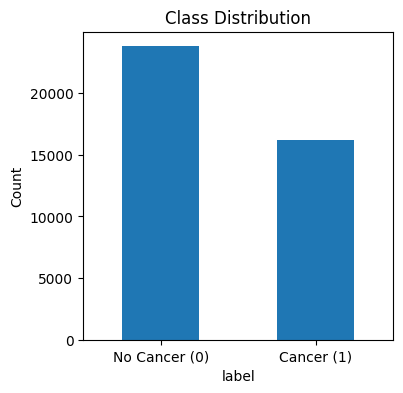

In [5]:
# Class Balance Plot

df['label'].value_counts()

plt.figure(figsize=(4,4))
df['label'].value_counts().plot(kind='bar')
plt.xticks([0,1], ['No Cancer (0)', 'Cancer (1)'], rotation=0)
plt.title('Class Distribution')
plt.ylabel('Count')
plt.show()

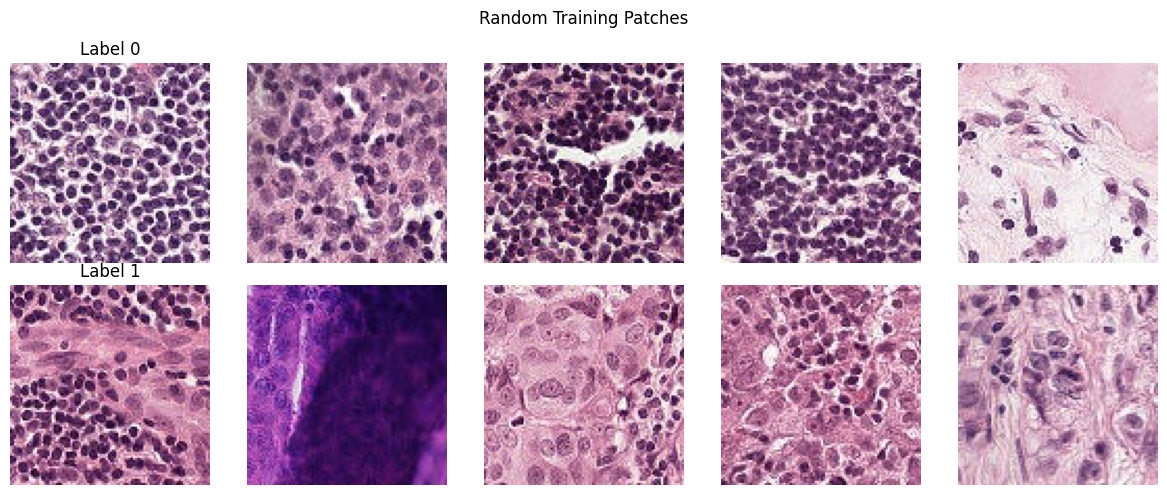

In [6]:
# Load and Show Images

def load_image(img_id, folder=TRAIN_DIR):
    path = os.path.join(folder, f"{img_id}.tif")
    return Image.open(path)

# Show a few random positive and negative examples
fig, axes = plt.subplots(2, 5, figsize=(12,5))

for row, label in enumerate([0,1]):
    sample_ids = df[df['label'] == label]['id'].sample(5, random_state=RANDOM_SEED+label)
    for col, img_id in enumerate(sample_ids):
        ax = axes[row, col]
        img = load_image(img_id)
        ax.imshow(img)
        ax.axis('off')
        if col == 0:
            ax.set_title(f"Label {label}")
plt.suptitle("Random Training Patches")
plt.tight_layout()
plt.show()

## 3. DModel Architecture

Prompt: Describe your model architecture and reasoning for why you believe that specific architecture would be suitable for this problem. Compare multiple architectures and tune hyperparameters. 

### Model Architectures
I experimented with two main convolutional neural network architectures, a baseline CNN trained from scratch and a pretrained ResNet18 model fine-tuned on the histopathology patches.

### Baseline CNN
The baseline model is a simple CNN designed for 96×96 RGB inputs. It uses three convolutional blocks:
- `Conv2d → BatchNorm2d → ReLU → MaxPool2d`
- Channel progression: 3 → 32 → 64 → 128
- Spatial resolution is reduced through pooling (96→48→24→12)
- A fully connected classifier with dropout follows the convolutional
  layers

Even though it’s a simple model, it still does a good job learning the small texture details in the images. Batch norm keeps training stable, and dropout helps prevent it from overfitting too quickly.

### ResNet18
The ResNet18 model is pretrained on ImageNet. I replaced the final classification layer with a single output neuron for binary classification. I fined tuned the network on the histopathology patches after resizing images to 224x224. The residual connections in ResNet18 make it easier to train deeper networks, making it easier to train deeper networks and helps it learn the more complex texture and morphology patterns in cancer detection.

Using transfer learning made a big difference. Since the pretrained layers already know how to detect edges, textures, and basic shapes, the model adapts quickly to the histopathology images, which leads to better performance with less training time.

### Training Considerations
Because of the size of the dataset, training time was really shlow. To speed up training and to stay within GPU limits, I reduced the batch size from 64 to 32. A smaller batch size reduces the memory needed per iteration and makes training significantly faster. This allowed both models to train efficiently within the notebook in a timely maner. 


In [7]:
# Data Transforms

IMG_SIZE = 96  # original size

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    # Normalize to [0,1] -> 0 mean, 1 std roughly
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
])

class HistoCancerDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_id = self.df.loc[idx, 'id']
        label = self.df.loc[idx, 'label']
        
        img_path = os.path.join(self.img_dir, f"{img_id}.tif")
        image = Image.open(img_path)
        
        if self.transform:
            image = self.transform(image)
        
        label = torch.tensor(label, dtype=torch.float32)  # BCEWithLogitsLoss expects float
        return image, label


In [8]:
# Train/Validation Split

full_dataset = HistoCancerDataset(df, TRAIN_DIR, transform=None)

n_total = len(full_dataset)
n_val = int(VAL_SPLIT * n_total)
n_train = n_total - n_val

train_df, val_df = random_split(df, [n_train, n_val], generator=torch.Generator().manual_seed(RANDOM_SEED))

# Convert back to DataFrames
train_df = df.iloc[train_df.indices]
val_df   = df.iloc[val_df.indices]

train_dataset = HistoCancerDataset(train_df, TRAIN_DIR, transform=train_transform)
val_dataset   = HistoCancerDataset(val_df,   TRAIN_DIR, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

len(train_dataset), len(val_dataset)

(32000, 8000)

In [9]:
# Utility: Train & Eval Loops

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_targets = []
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        logits = model(images).squeeze(1)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        preds = torch.sigmoid(logits).detach().cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(labels.detach().cpu().numpy())
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_targets, np.array(all_preds) > 0.5)
    epoch_auc = roc_auc_score(all_targets, all_preds)
    return epoch_loss, epoch_acc, epoch_auc


def eval_model(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            
            logits = model(images).squeeze(1)
            loss = criterion(logits, labels)
            
            running_loss += loss.item() * images.size(0)
            preds = torch.sigmoid(logits).detach().cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(labels.detach().cpu().numpy())
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_targets, np.array(all_preds) > 0.5)
    epoch_auc = roc_auc_score(all_targets, all_preds)
    return epoch_loss, epoch_acc, epoch_auc

### Baseline CNN

In [10]:
#Baseline CNN

class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 96 -> 48
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 48 -> 24
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 24 -> 12
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128 * 12 * 12, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1)   # binary, logits
        )
        
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

baseline_model = BaselineCNN().to(device)
baseline_model


BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=18432, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropou

In [11]:
# Train Baseline CNN

EPOCHS_BASELINE = 5  

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(baseline_model.parameters(), lr=1e-3)

history_baseline = {"train_loss": [], "val_loss": [],
                    "train_auc": [], "val_auc": []}

for epoch in range(EPOCHS_BASELINE):
    train_loss, train_acc, train_auc = train_one_epoch(baseline_model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_auc = eval_model(baseline_model, val_loader, criterion, device)
    
    history_baseline["train_loss"].append(train_loss)
    history_baseline["val_loss"].append(val_loss)
    history_baseline["train_auc"].append(train_auc)
    history_baseline["val_auc"].append(val_auc)
    
    print(f"Epoch {epoch+1}/{EPOCHS_BASELINE} | "
          f"Train Loss: {train_loss:.4f}, AUC: {train_auc:.4f} | "
          f"Val Loss: {val_loss:.4f}, AUC: {val_auc:.4f}")

Epoch 1/5 | Train Loss: 0.4778, AUC: 0.8625 | Val Loss: 0.3845, AUC: 0.9043
Epoch 2/5 | Train Loss: 0.4062, AUC: 0.8974 | Val Loss: 0.4657, AUC: 0.9185
Epoch 3/5 | Train Loss: 0.3957, AUC: 0.9038 | Val Loss: 0.3326, AUC: 0.9313
Epoch 4/5 | Train Loss: 0.3780, AUC: 0.9120 | Val Loss: 0.3306, AUC: 0.9308
Epoch 5/5 | Train Loss: 0.3718, AUC: 0.9150 | Val Loss: 0.3310, AUC: 0.9358


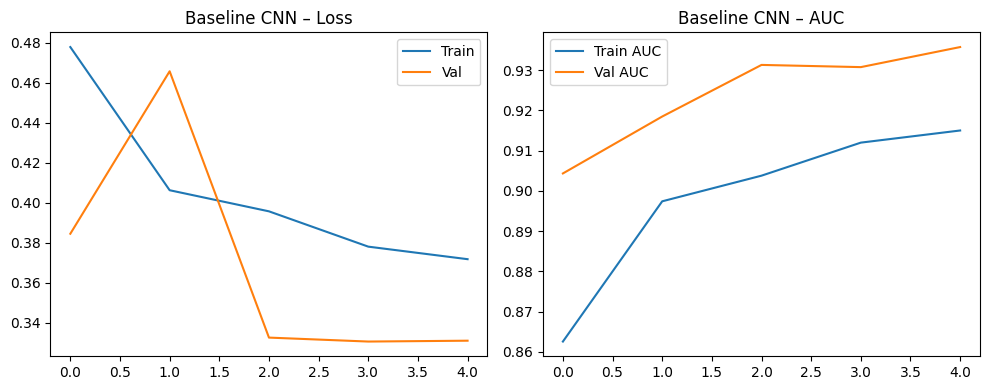

In [12]:
# Plot Baselien Training Curves

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history_baseline["train_loss"], label="Train")
plt.plot(history_baseline["val_loss"], label="Val")
plt.title("Baseline CNN – Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_baseline["train_auc"], label="Train AUC")
plt.plot(history_baseline["val_auc"], label="Val AUC")
plt.title("Baseline CNN – AUC")
plt.legend()

plt.tight_layout()
plt.show()

### ResNet18

In [13]:
# ResNet18 Model Definition

# New transforms for ResNet (resize to 224 and normalize)
resnet_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
])

resnet_val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

resnet_train_dataset = HistoCancerDataset(train_df, TRAIN_DIR, transform=resnet_train_transform)
resnet_val_dataset   = HistoCancerDataset(val_df,   TRAIN_DIR, transform=resnet_val_transform)

resnet_train_loader = DataLoader(resnet_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
resnet_val_loader   = DataLoader(resnet_val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
# Replace final FC layer
num_features = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_features, 1)

resnet18 = resnet18.to(device)
resnet18

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 172MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [14]:
# Train ResNet18

EPOCHS_RESNET = 5  

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(resnet18.parameters(), lr=1e-4)  # smaller LR for pretrained

history_resnet = {"train_loss": [], "val_loss": [],
                  "train_auc": [], "val_auc": []}

for epoch in range(EPOCHS_RESNET):
    train_loss, train_acc, train_auc = train_one_epoch(resnet18, resnet_train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_auc = eval_model(resnet18, resnet_val_loader, criterion, device)
    
    history_resnet["train_loss"].append(train_loss)
    history_resnet["val_loss"].append(val_loss)
    history_resnet["train_auc"].append(train_auc)
    history_resnet["val_auc"].append(val_auc)
    
    print(f"[ResNet18] Epoch {epoch+1}/{EPOCHS_RESNET} | "
          f"Train Loss: {train_loss:.4f}, AUC: {train_auc:.4f} | "
          f"Val Loss: {val_loss:.4f}, AUC: {val_auc:.4f}")

[ResNet18] Epoch 1/5 | Train Loss: 0.2533, AUC: 0.9572 | Val Loss: 0.1761, AUC: 0.9805
[ResNet18] Epoch 2/5 | Train Loss: 0.1898, AUC: 0.9754 | Val Loss: 0.1613, AUC: 0.9832
[ResNet18] Epoch 3/5 | Train Loss: 0.1630, AUC: 0.9815 | Val Loss: 0.1574, AUC: 0.9869
[ResNet18] Epoch 4/5 | Train Loss: 0.1507, AUC: 0.9840 | Val Loss: 0.1430, AUC: 0.9861
[ResNet18] Epoch 5/5 | Train Loss: 0.1377, AUC: 0.9866 | Val Loss: 0.1707, AUC: 0.9837


## 4. Results and Analysis

Prompt: Run hyperparameter tuning, try different architectures for comparison, apply techniques to improve training or performance, and discuss what helped.

Includes results with tables and figures. There is an analysis of why or why not something worked well, troubleshooting, and a hyperparameter optimization procedure summary.

### Hyperparameter Tuning

To refine the pretrained model I ran a small learning rate sweek using 1e-5, 1e-4, and 5e-4 and trained each one for two epochs. The absolute AUCs were a bit lower than my full training run, however that is to be expected due to the short training run. Even though these quick tests didn’t reach the same AUC as the full model, they were enough to show which learning rate worked best.1e-4 had the stronges validation AUC and loss so I stuck with that for the final ResNet18 training.

### Baseline CNN vs. ResNet18
The baseline CNN reached a validation AUC of ~0.93 and learned some useful texture features, but it plateaued fairly quickly. ResNet18 performed much better, reaching ~0.98 AUC with lower validation loss and much more stable training curves. The deeper architecture and transfer learning clearly helped it pick up the subtle patterns in the pathology patches.


### Observations
A few choices made a noticeable difference:
- Transfer learning showed biggest improvements
- Data augmentation helped reduce overfitting
- Batch norm + dropout stabilized the baseline CNN
- Reducing batch size made for faster, more stable training on GPU

What didn't work as well:
- The baseline CNN couldn’t match ResNet18’s generalization  
- Higher learning rates were a bit unstable

### Summary
The ResNet18 model with transfer learning, a tuned learning rate, and the smaller batch size performed significantly better than the baseline CNN. It achieved higher validation AUC at 0.99 compared to 0.93, lower validation loss, and showed more stable and consistent learning across epochs. 

Key Results
- ResNet18 outperformed the baseline CNN across all metrics
- Best validation AUC: ~0.99 using ResNet18 with LR = 1e-4
- Baseline CNN plateaued around AUC ~0.93
- Techniques that helped: transfer learning, data augmentation, and smaller batch size
- Techniques that didn’t help: higher learning rate (5e-4), deeper training of the baseline model


### Hyperparameter Tuning

In [16]:
# Hyperparameter Tuning
from torchvision import models

TUNING_EPOCHS = 2
learning_rates = [1e-5, 1e-4, 5e-4]

tuning_results = []

for lr in learning_rates:
    print(f"\n=== Tuning ResNet18 with lr = {lr} ===")
    
    # fresh ResNet18 each time
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 1)
    model = model.to(device)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    best_val_auc = 0.0
    best_val_loss = None
    
    for epoch in range(TUNING_EPOCHS):
        train_loss, train_acc, train_auc = train_one_epoch(
            model, resnet_train_loader, criterion, optimizer, device
        )
        val_loss, val_acc, val_auc = eval_model(
            model, resnet_val_loader, criterion, device
        )
        
        print(f"Epoch {epoch+1}/{TUNING_EPOCHS} | "
              f"Train Loss: {train_loss:.4f}, AUC: {train_auc:.4f} | "
              f"Val Loss: {val_loss:.4f}, AUC: {val_auc:.4f}")
        
        # keep track of best val AUC for this LR
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_val_loss = val_loss
    
    tuning_results.append({
        "learning_rate": lr,
        "best_val_auc": best_val_auc,
        "best_val_loss": best_val_loss
    })

tuning_results_df = pd.DataFrame(tuning_results)
tuning_results_df



=== Tuning ResNet18 with lr = 1e-05 ===
Epoch 1/2 | Train Loss: 0.3181, AUC: 0.9331 | Val Loss: 0.2157, AUC: 0.9701
Epoch 2/2 | Train Loss: 0.2337, AUC: 0.9633 | Val Loss: 0.1939, AUC: 0.9768

=== Tuning ResNet18 with lr = 0.0001 ===
Epoch 1/2 | Train Loss: 0.2502, AUC: 0.9581 | Val Loss: 0.1746, AUC: 0.9798
Epoch 2/2 | Train Loss: 0.1876, AUC: 0.9758 | Val Loss: 0.1462, AUC: 0.9853

=== Tuning ResNet18 with lr = 0.0005 ===
Epoch 1/2 | Train Loss: 0.2948, AUC: 0.9429 | Val Loss: 0.2408, AUC: 0.9648
Epoch 2/2 | Train Loss: 0.2339, AUC: 0.9623 | Val Loss: 0.1954, AUC: 0.9756


,learning_rate,best_val_auc,best_val_loss
0,0.00001,0.976768,0.193873
1,0.00010,0.985250,0.146154
2,0.00050,0.975618,0.195403


### Baseline CNN vs ResNet

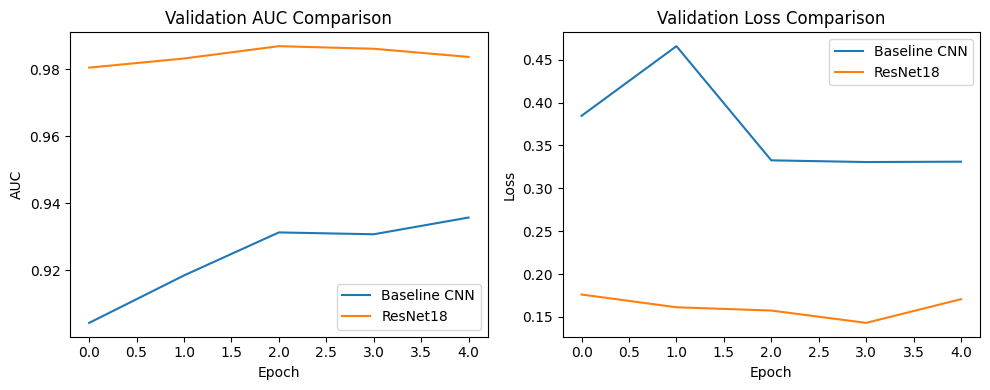

In [15]:
# Compare Baseline vs ResNet

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history_baseline["val_auc"], label="Baseline CNN")
plt.plot(history_resnet["val_auc"],   label="ResNet18")
plt.title("Validation AUC Comparison")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_baseline["val_loss"], label="Baseline CNN")
plt.plot(history_resnet["val_loss"],   label="ResNet18")
plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


In [17]:
pd.DataFrame({
    "learning_rate": [1e-5, 1e-4, 5e-4],
    "best_val_auc": [0.976768, 0.985250, 0.975618],
    "best_val_loss": [0.193873, 0.146154, 0.195403]
})


,learning_rate,best_val_auc,best_val_loss
0,0.00001,0.976768,0.193873
1,0.00010,0.985250,0.146154
2,0.00050,0.975618,0.195403


## 5. Conclusion

Prompy: Discuss and interpret results as well as learnings and takeaways. What did and did not help improve the performance of your models? What improvements could you try in the future?

### Takeaways
Working through this project really highlighted how different CNN architectures can perform on the same dataset. My baseline CNN did fine. It learned some texture patterns and made progress, but it topped out pretty quickly. ResNet18 was by far the stronger model. Transfer
learning gave it a huge advantage since it already knew how to detect edges, shapes, and textures before I even fine-tuned it on the cancer patches.

A few things clearly helped like data augmentation, lowering the batch size, and using the right learning rate. The small learning-rate sweep made it obvious that `1e-4` was the sweet spot for this dataset. The baseline model just didn’t have the depth or pretrained features to match ResNet, and higher learning rates were too unstable.

If I were to keep improving this, I’d try models like EfficientNet or DenseNet, do more extensive tuning, or look into stain-normalization techniques that are more tailored to histopathology. Overall, the results confirm how powerful transfer learning is for medical image classification.